In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv


In [2]:
import pandas as pd
new_data=pd.read_csv('/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv')
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
import pandas as pd

In [4]:
new_data.columns=new_data.columns.str.replace(' ','_' ,regex=False)
new_data['Postal_Code']=new_data['Postal_Code'].fillna(0).astype(int)

new_data.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
new_data['Order_Date']=pd.to_datetime(new_data['Order_Date'],format='%d/%m/%Y')
new_data['Ship_Date']=pd.to_datetime(new_data['Ship_Date'],format='%d/%m/%Y')
new_data

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [6]:
print(new_data[['Order_Date','Ship_Date']].dtypes)

Order_Date    datetime64[ns]
Ship_Date     datetime64[ns]
dtype: object


In [7]:
dim_customer=new_data[['Customer_ID','Customer_Name','Segment']].drop_duplicates(subset=['Customer_ID'])
dim_product=new_data[['Product_ID','Product_Name','Category','Sub-Category']].drop_duplicates(subset=['Product_ID'])
fact_sale=new_data[['Row_ID','Order_ID','Order_Date','Ship_Date','Ship_Mode','Country','City','State','Postal_Code','Region','Sales','Customer_ID','Product_ID']]
print(dim_customer.shape,dim_product.shape,fact_sale.shape)

(793, 3) (1861, 4) (9800, 13)


In [8]:
dim_product.head(1)

,Product_ID,Product_Name,Category,Sub-Category
0,FUR-BO-10001798,Bush Somerset Collection Bookcase,Furniture,Bookcases


In [9]:
dim_customer.head(1)

,Customer_ID,Customer_Name,Segment
0,CG-12520,Claire Gute,Consumer


In [10]:
fact_sale.head(1)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Country,City,State,Postal_Code,Region,Sales,Customer_ID,Product_ID
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,United States,Henderson,Kentucky,42420,South,261.96,CG-12520,FUR-BO-10001798


In [11]:
import duckdb as db
db.register('dim_customer',dim_customer)
db.register('dim_product',dim_product)
db.register('fact_sale',fact_sale)
result1=db.query(""" 
with new as(
select d.Category as category,d."Sub-Category" as sub_category,sum(f.Sales),dense_rank() over(partition by d.Category order by sum(f.Sales) desc) as ranks
from fact_sale f
inner join dim_product d on d.Product_ID=f.Product_ID
group by d.Category,d."Sub-Category"
)
select * 
from new
where ranks<=3
""").df()
print(result1)

          category sub_category  sum(f.Sales)  ranks
0        Furniture       Chairs   322822.7310      1
1        Furniture       Tables   202810.6280      2
2        Furniture    Bookcases   113813.1987      3
3       Technology  Accessories   164186.7000      3
4       Technology       Phones   327782.4480      1
5       Technology     Machines   189238.6310      2
6  Office Supplies      Storage   219343.3920      1
7  Office Supplies      Binders   200028.7850      2
8  Office Supplies   Appliances   104618.4030      3


In [12]:
import duckdb as db
result2=db.query("""
select d.Customer_Name,d.Segment,round(sum(f.Sales),2) as sales,count(distinct f.Order_ID) as unique_orders
from dim_customer d
inner join fact_sale f on d.Customer_ID=f.Customer_ID
group by d.Customer_Name,d.Segment
order by sum(f.Sales) desc
limit 5
""").df()
print(result2)

   Customer_Name      Segment     sales  unique_orders
0    Sean Miller  Home Office  25043.05              5
1   Tamara Chand    Corporate  19052.22              5
2   Raymond Buch     Consumer  15117.34              6
3   Tom Ashbrook  Home Office  14595.62              4
4  Adrian Barton     Consumer  14473.57             10


In [13]:
fact_sale.head(5)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Country,City,State,Postal_Code,Region,Sales,Customer_ID,Product_ID
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,United States,Henderson,Kentucky,42420,South,261.9600,CG-12520,FUR-BO-10001798
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,United States,Henderson,Kentucky,42420,South,731.9400,CG-12520,FUR-CH-10000454
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,United States,Los Angeles,California,90036,West,14.6200,DV-13045,OFF-LA-10000240
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,United States,Fort Lauderdale,Florida,33311,South,957.5775,SO-20335,FUR-TA-10000577
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,United States,Fort Lauderdale,Florida,33311,South,22.3680,SO-20335,OFF-ST-10000760


In [14]:
import duckdb as db
result3=db.query("""
with new as
(select year(Order_Date) as year,Month(Order_date) as month,round(sum(Sales),2) as monthly_sales
from fact_sale
group by year(Order_Date),month(Order_Date)

)
select *,
sum(monthly_sales) over(partition by year order by month asc) as rolling_sum
from new
order by year asc,month asc

""").df()
print(result3.head(12))


    year  month  monthly_sales  rolling_sum
0   2015      1       14205.71     14205.71
1   2015      2        4519.89     18725.60
2   2015      3       55205.80     73931.40
3   2015      4       27906.85    101838.25
4   2015      5       23644.30    125482.55
5   2015      6       34322.94    159805.49
6   2015      7       33781.54    193587.03
7   2015      8       27117.54    220704.57
8   2015      9       81623.53    302328.10
9   2015     10       31453.39    333781.49
10  2015     11       77907.66    411689.15
11  2015     12       68167.06    479856.21


In [15]:
import pandas as pd
result3['year_month']=result3['year'].astype(str)+'-'+result3['month'].astype(str)
result3.head(1)

,year,month,monthly_sales,rolling_sum,year_month
0,2015,1,14205.71,14205.71,2015-1


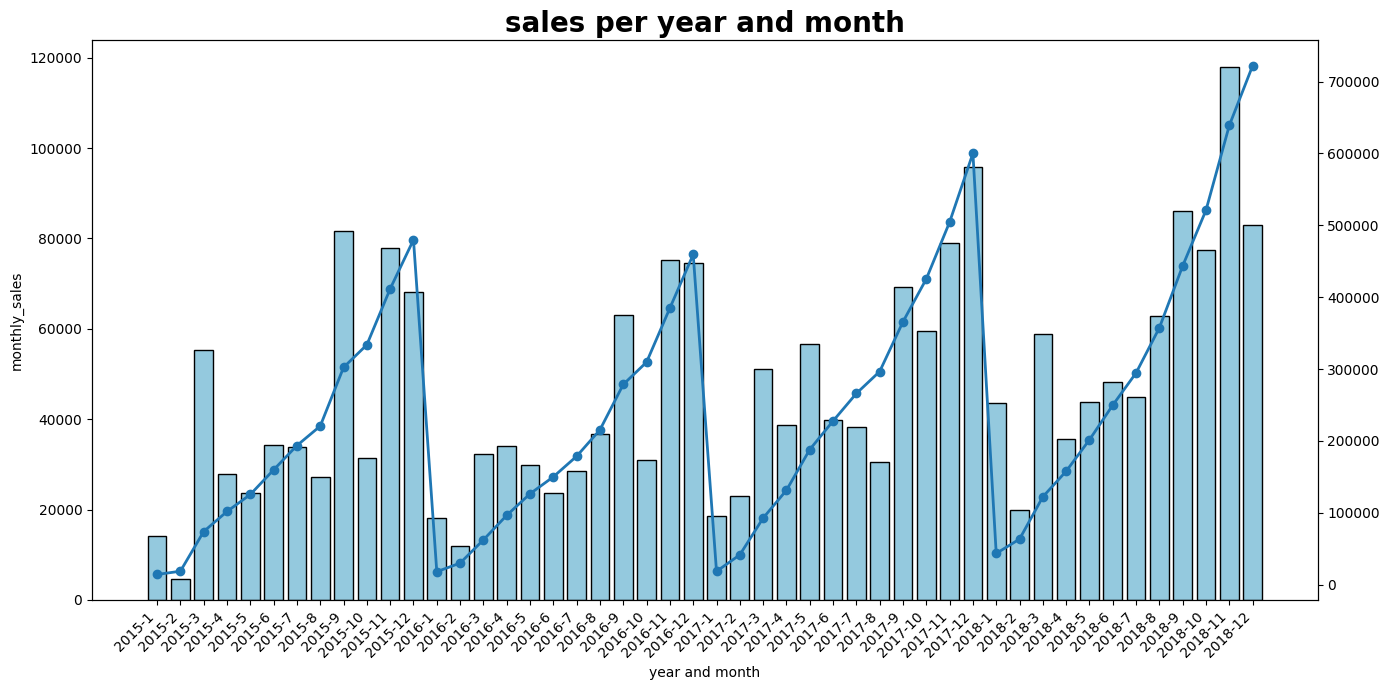

In [16]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import FuncFormatter
import seaborn as sns

fig,ax1=plt.subplots(figsize=(14,7))
sns.barplot(
     data=result3,
     x='year_month',
     y='monthly_sales',
     color='skyblue',
     edgecolor='black'
     
)
plt.title('sales per year and month',fontsize=20,fontweight='bold')
plt.xlabel('year and month')
plt.ylabel('monthly_sales')
plt.xticks(rotation=45,ha='right')
ax2=ax1.twinx()
ax2.plot(result3['year_month'],result3['rolling_sum'],linewidth=2,marker='o')
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
fact_table=pd.read_csv('/kaggle/working/fact_table.csv')

In [27]:
print(fact_table.columns.tolist())


['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Sales', 'Customer_ID', 'Product_ID']


/tmp/ipykernel_58/3746668553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_table,x='Category',y='Sales',ax=axes,palette='Blues')


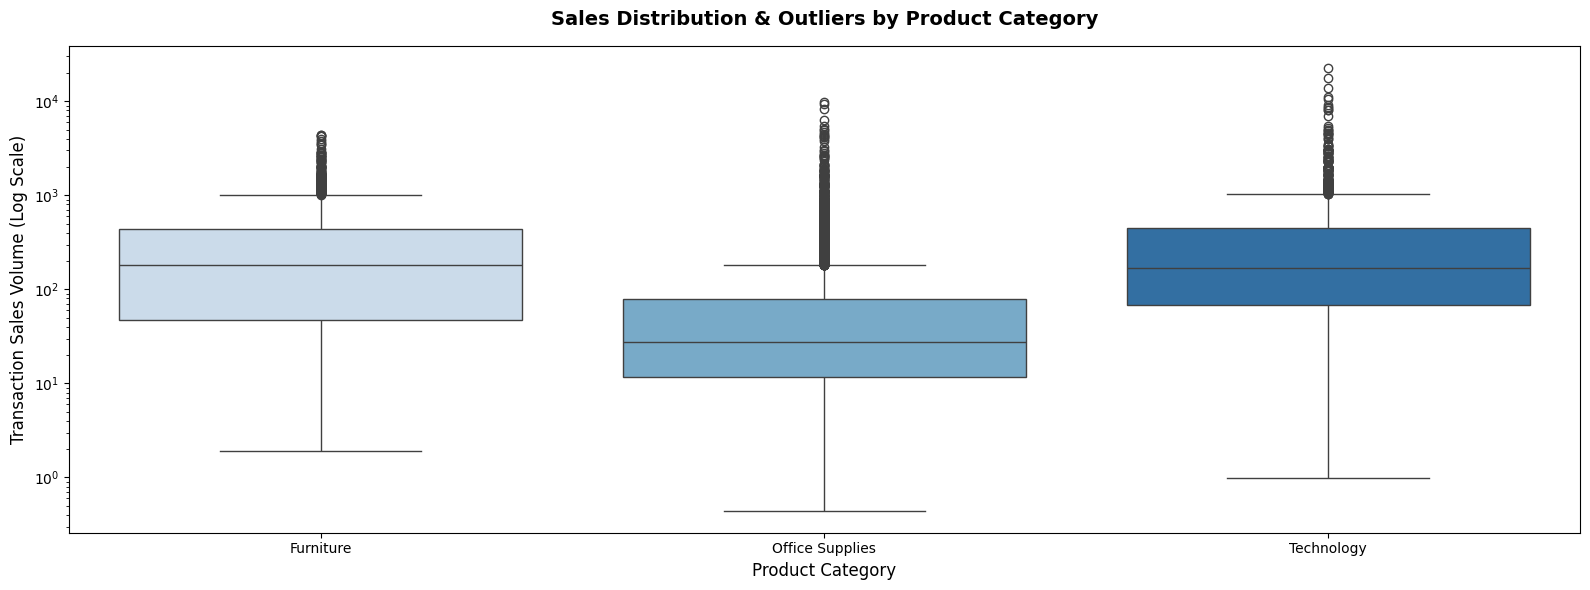

In [33]:

plot_table=pd.merge(fact_table,dim_product,on='Product_ID',how='inner')
fig,axes=plt.subplots(figsize=(16,6))
sns.boxplot(data=plot_table,x='Category',y='Sales',ax=axes,palette='Blues')
axes.set_yscale('log')
axes.set_title('Sales Distribution & Outliers by Product Category', fontsize=14, fontweight='bold', pad=15)
axes.set_xlabel('Product Category', fontsize=12)
axes.set_ylabel('Transaction Sales Volume (Log Scale)', fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
dim_customer.to_csv('dim_customer.csv',index=False)
dim_product.to_csv('dim_product.csv',index=False)
fact_sale.to_csv('fact_table.csv',index=False)